In [10]:
"""
Reproduction code for the paper:
"Affective Dynamics Under Contradictory Stimulation: A Stochastic Model"
(JASSS submission)

Generates:
- Fig. 8 (trimodal distribution) → 3picos.pdf
- Fig. 44 (bimodal distribution) → noises_b_m.pdf

Method: Euler–Maruyama (Itô SDE) with correlated Wiener processes.
Memory‑friendly version: stores only the time slices needed for plotting.
"""

import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

def simulate(x0, m, b, c, sigma1, sigma2, rho, T=10.0, M=100, I=100000,
             drift_extra=None, seed=None, g1_is_x=False,
             record_times=None):
    """
    Run the 2‑noise simulation, storing only the time steps specified.

    Parameters
    ----------
    record_times : list of float, optional
        Times at which to store the full array of trajectories.
        If None, defaults to [0.1, 5.0, 10.0] (used by most figures).
    Returns
    -------
    dict : {time_label: ndarray of shape (I,)}
        e.g. {'t=0.1': samples, 't=5.0': samples, 't=10': samples}
    """
    dt = T / M
    cho = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]]))

    if seed is not None:
        np.random.seed(seed)

    if record_times is None:
        record_times = [0.1, 5.0, 10.0]

    # Convert times to step indices
    record_steps = {t: round(t / dt) for t in record_times}
    max_step = max(record_steps.values()) + 1

    # Current state for all trajectories
    x = np.full(I, x0, dtype=np.float32)

    # Dictionary to store recorded slices
    recorded = {}

    # Drift function
    def f(x):
        return m * x + b + c * np.tanh(x)

    if g1_is_x:
        def g1(x):
            return sigma1 * x
    else:
        def g1(x):
            return sigma1 * np.tanh(x)

    def g2(x):
        return sigma2

    for t in range(1, M + 1):
        # Generate correlated Wiener increments for this step
        eps = npr.standard_normal((2, I))
        dW = np.sqrt(dt) * np.dot(cho, eps)
        dW1 = dW[0]
        dW2 = dW[1]

        drift = f(x) + (drift_extra(x) if drift_extra else 0.0)
        x = x + drift * dt + g1(x) * dW1 + g2(x) * dW2

        # Record if this step is needed
        for time_val, step_idx in record_steps.items():
            if t == step_idx:
                recorded[time_val] = x.copy()

    return recorded

def plot_figure(recorded, times, labels, bins, filename, xlim, title):
    """Plot overlaid histograms from recorded time slices."""
    fig = plt.figure()
    plt.title(title)
    colors = ['r', 'g', 'b']
    for t_val, label, color, b in zip(times, labels, colors, bins):
        samples = recorded[t_val]
        plt.hist(samples, bins=b, density=True, histtype='stepfilled',
                 color=color, label=label, alpha=0.3 if color != 'b' else 0.8)
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.xlim(xlim)
    plt.legend()
    fig.savefig(filename)
    plt.close()

if __name__ == '__main__':
    print("Generating Fig. 8 (3picos.pdf) ...")
    # Fig. 8 parameters
    rec8 = simulate(
        x0=10, m=-0.4, b=0.8, c=7.0,
        sigma1=15.0, sigma2=1.0, rho=0.3,
        T=10.0, M=100, I=100000,
        seed=42,
        g1_is_x=False,
        record_times=[0.3, 1.0, 10.0]
    )
    plot_figure(
        rec8,
        times=[0.3, 1.0, 10.0],
        labels=['t=0.3', 't=1.0', 't=10'],
        bins=[100, 200, 300],
        filename='3picos.pdf',
        xlim=[-50, 50],
        title='Probability Density Function P(x,t)'
    )
    print("   saved 3picos.pdf")

    print("Generating Fig. 44 (noises_b_m.pdf) ...")
    # Fig. 44 parameters (noise in inertia: g1(x) = sigma1 * x)
    rec44 = simulate(
        x0=10, m=-1.0, b=1.0, c=5.0,
        sigma1=1.0, sigma2=1.3, rho=0.6,
        T=10.0, M=100, I=200000,
        seed=123,
        g1_is_x=True,
        record_times=[0.1, 5.0, 10.0]
    )
    plot_figure(
        rec44,
        times=[0.1, 5.0, 10.0],
        labels=['t=0.1', 't=5.0', 't=10'],
        bins=[100, 3000, 3000],
        filename='noises_b_m.pdf',
        xlim=[-10, 20],
        title='Probability Density Function P(x,t)'
    )
    print("   saved noises_b_m.pdf")
    print("Done.")

Generating Fig. 8 (3picos.pdf) ...
   saved 3picos.pdf
Generating Fig. 44 (noises_b_m.pdf) ...
   saved noises_b_m.pdf
Done.


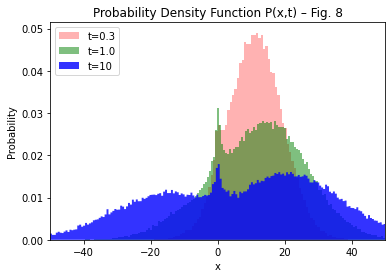

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

# Figura 8 (trimodal)
plt.figure()
plt.title('Probability Density Function P(x,t) – Fig. 8')
plt.hist(rec8[0.3], bins=100, density=True, histtype='stepfilled', color='r', label='t=0.3', alpha=0.3)
plt.hist(rec8[1.0], bins=200, density=True, histtype='stepfilled', color='g', label='t=1.0', alpha=0.5)
plt.hist(rec8[10.0], bins=300, density=True, histtype='stepfilled', color='b', label='t=10', alpha=0.8)
plt.xlabel('x')
plt.ylabel('Probability')
plt.xlim([-50, 50])
plt.legend()
plt.show()

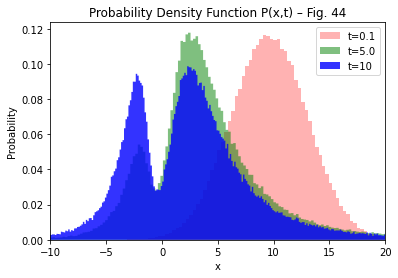

In [12]:
# Figura 44 (bimodal – ruído na inércia)
plt.figure()
plt.title('Probability Density Function P(x,t) – Fig. 44')
plt.hist(rec44[0.1], bins=100, density=True, histtype='stepfilled', color='r', label='t=0.1', alpha=0.3)
plt.hist(rec44[5.0], bins=3000, density=True, histtype='stepfilled', color='g', label='t=5.0', alpha=0.5)
plt.hist(rec44[10.0], bins=3000, density=True, histtype='stepfilled', color='b', label='t=10', alpha=0.8)
plt.xlabel('x')
plt.ylabel('Probability')
plt.xlim([-10, 20])
plt.legend()
plt.show()